In [1]:
import numpy as np
import matplotlib.pyplot as plt

# PCA

In [25]:
from sklearn.decomposition import PCA, KernelPCA
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

(200, 3)


Text(0.5, 1.0, 'X_proj - explained var: 1.00')

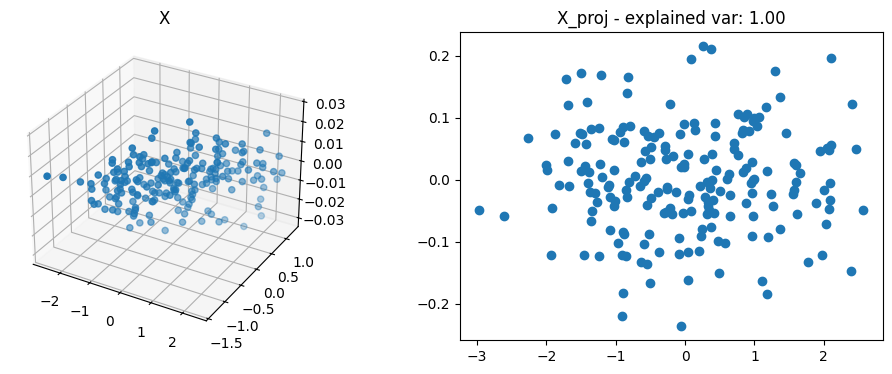

In [12]:
# On génère des données 2D fortement corrélées + 1 dimension à faible variance
np.random.seed(0)
n_samples = 200
X1 = np.random.randn(n_samples)
X2 = 0.5 * X1 + 0.1 * np.random.randn(n_samples)
X3 = 0.01 * np.random.randn(n_samples)
X = np.column_stack((X1, X2, X3))


pca = PCA()
pca =  pca.fit(X)
x_proj = pca.transform(X)

print(x_proj.shape)

fig = plt.figure(figsize=(12, 4))

ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter3D(X[:, 0], X[:, 1], X[:, 2])
ax1.set_title("X")

ax2 = fig.add_subplot(122)
ax2.scatter(x_proj[:, 0], x_proj[:, 1])
ax2.set_title(f"X_proj - explained var: {sum(pca.explained_variance_ratio_):.2f}")

In [21]:
print(
    "n_components_", pca.n_components_,'\n',
    "components_", pca.components_,'\n',
    "explained_variance_", pca.explained_variance_,'\n',
    "explained_variance_ratio_", pca.explained_variance_ratio_
)

n_components_ 3 
 components_ [[ 8.90683646e-01  4.54623403e-01 -4.52898601e-04]
 [-4.54492282e-01  8.90449819e-01  2.31491889e-02]
 [ 1.09274465e-02 -2.04127651e-02  9.99731919e-01]] 
 explained_variance_ [1.31988469e+00 7.06690934e-03 1.02936628e-04] 
 explained_variance_ratio_ [9.94597173e-01 5.32525918e-03 7.75677455e-05]


* PCA vs KernelPCA

In [24]:
# 1) Génération de données : cercles imbriqués
X, y = make_circles(n_samples=1000, factor=0.3, noise=0.05, random_state=0)

In [35]:
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=0)

Text(0.5, 1.0, 'kpca')

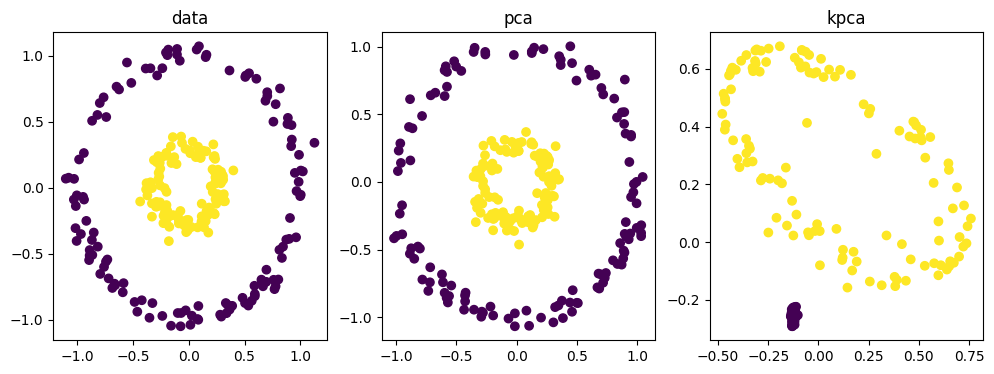

In [41]:
x_test_pca = PCA().fit(x_train).transform(x_test)

x_test_kpca = KernelPCA(kernel='rbf', degree=3, gamma=10, fit_inverse_transform=True, alpha=0.1).fit(x_train).transform(x_test)

fig, (ax_data, ax_pca, ax_kpca) = plt.subplots(ncols=3, figsize=(12, 4))

ax_data.scatter(x_test[:,0], x_test[:,1], c=y_test)
ax_data.set_title("data")

ax_pca.scatter(x_test_pca[:,0], x_test_pca[:,1], c=y_test)
ax_pca.set_title("pca")

ax_kpca.scatter(x_test_kpca[:,0], x_test_kpca[:,1], c=y_test)
ax_kpca.set_title("kpca")

# TSNE

In [44]:
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

In [43]:
digits = load_digits()
x = digits.data
y = digits.target
print(x.shape, y.shape)

(1797, 64) (1797,)


In [48]:
x_scaled = StandardScaler().fit_transform(x)

tsne_2d = TSNE(n_components=2, perplexity=30, 
            early_exaggeration=12, learning_rate='auto').fit_transform(x_scaled)


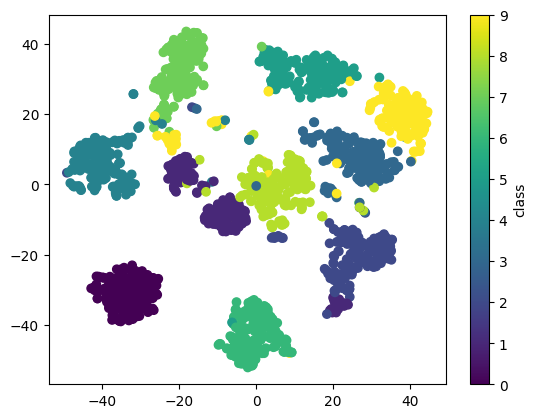

In [50]:
scatter = plt.scatter(tsne_2d[:,0], tsne_2d[:,1], c=y)
plt.colorbar(scatter, label="class")

# Isomap

In [51]:
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import Isomap
from sklearn.decomposition import PCA

In [52]:
x, y = make_swiss_roll(n_samples=1500, random_state=42)

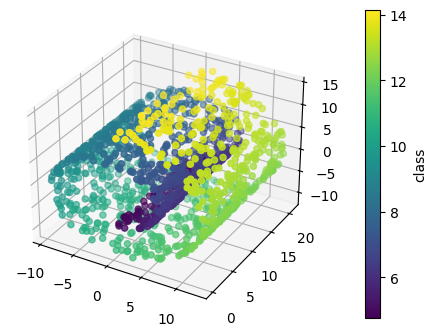

In [61]:
fig = plt.figure(figsize=(12, 4))

ax_data = fig.add_subplot(111, projection='3d')
scatter = ax_data.scatter3D(x[:,0], x[:,1], x[:,2], c=y)
plt.colorbar(scatter, label="class")

Text(0.5, 1.0, 'ISOMAP')

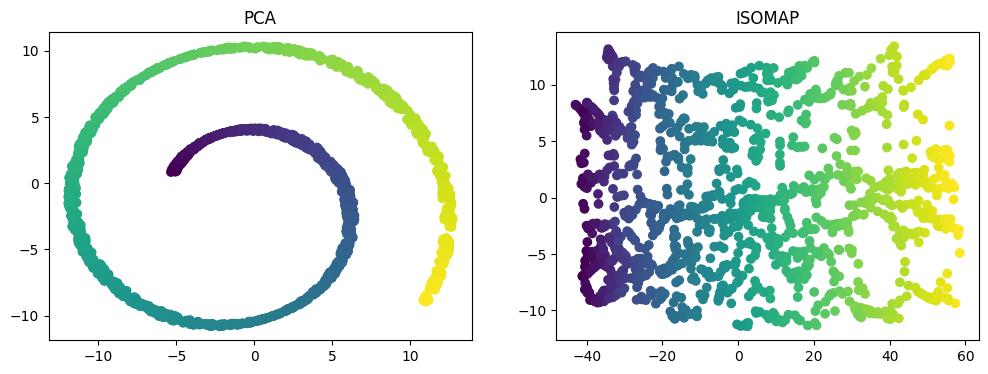

In [63]:
#PCA
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x)
#Isomap
isomap = Isomap(n_neighbors=5, n_components=2)
x_isomap = isomap.fit_transform(x)

fig, (ax_pca, ax_isomap) = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))

#graph pca
ax_pca.scatter(x_pca[:,0], x_pca[:,1], c=y)
ax_pca.set_title("PCA")

#graph isomap
ax_isomap.scatter(x_isomap[:,0], x_isomap[:,1], c=y)
ax_isomap.set_title("ISOMAP")




